# 02-01 - The Municipality Measures in Feet

In P01 every file we opened was in degrees, and we converted it to metres before measuring anything. Today the files are Princeton's own. They are published by the municipality and by the State of New Jersey, and they arrive in a coordinate system we have named but never held, New Jersey State Plane, measured in US survey feet, and on two different versions of the datum at once.

We open the file and read what it says about itself. We make the mistake the lecture warned about, on real municipal data, and then a second mistake that draws a picture nobody would trust and raises nothing. We meet a warning that is easy to ignore and should not be. We watch two offices measure the same town and one typed column disagree with both, and we check a file against itself, where every inlet is recorded twice. And we end by finding the row behind our own classroom, which is what QGIS does with a click and we do with a line.

Before you run anything, choose *File*, then *Save As*, and give the copy a name with `-mywork` in it, so that next week's pull never collides with your work.

In [1]:
import json

import geopandas as gpd
import pyogrio
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 72

## What is in the box

In P01 every dataset was its own GeoJSON file. This week the municipality's layers come as one file, `princeton_municipal.gpkg`, which is a **GeoPackage**, i.e. a single file that can hold many layers, each with its own geometry, its own columns and its own coordinate reference system. It is the format QGIS reads by default, and it is the format the December poster's data will be in.

The first thing to do with a box is to look inside it, and geopandas has a function for exactly that:

In [2]:
gpd.list_layers("data/princeton_municipal.gpkg")

,name,geometry_type
0,boundary,Polygon
1,zoning,MultiPolygon
2,tax_blocks,Polygon
3,parcels,MultiPolygon
4,roads,LineString
5,deer_reports,Point
6,stormwater_inlets,Point


Seven layers, and the table already tells us something about each. The boundary and the tax blocks are polygons, the roads are lines, and the deer reports and the stormwater inlets are points. Every one of them is a table with a geometry column, i.e. a GeoDataFrame once we read it, which is exactly what P01 taught us to handle.

Note that a GeoJSON file could not have shown us a list like this. It holds one layer, and by the rules of its own standard it holds that layer in degrees. A GeoPackage records whatever coordinate system the publisher used, and every layer can carry its own, so let us ask all seven at once what they arrived in and how many rows each holds:

In [3]:
for name in gpd.list_layers("data/princeton_municipal.gpkg")["name"]:
    layer = gpd.read_file("data/princeton_municipal.gpkg", layer=name)
    print(f"{name:18} {layer.crs.to_string():10} {len(layer):6,} rows")

boundary           EPSG:3424       1 rows
zoning             EPSG:6527     126 rows
tax_blocks         EPSG:3424     484 rows
parcels            EPSG:6527   8,874 rows
roads              EPSG:6527   1,782 rows
deer_reports       EPSG:6527     492 rows
stormwater_inlets  EPSG:6527   4,455 rows


Two different codes for one publisher's seven layers, and every one of them in feet. Keep this table in view. At the end of the session an agent will be asked to report the same numbers, and this is what you check it against.

## Reading what the file says about itself

Now the zoning layer alone. Let us read it and ask it, before anything else, what its two numbers mean:

In [4]:
zoning = gpd.read_file("data/princeton_municipal.gpkg", layer="zoning")
zoning.crs

<Projected CRS: EPSG:6527>
Name: NAD83(2011) / New Jersey (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - New Jersey - counties of Atlantic; Bergen; Burlington; Camden; Cape May; Cumberland; Essex; Gloucester; Hudson; Hunterdon; Mercer; Middlesex; Monmouth; Morris; Ocean; Passaic; Salem; Somerset; Sussex; Union; Warren.
- bounds: (-75.6, 38.87, -73.88, 41.36)
Coordinate Operation:
- name: SPCS83 New Jersey zone (US survey foot)
- method: Transverse Mercator
Datum: NAD83 (National Spatial Reference System 2011)
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

A whole card, headed `EPSG:6527`, a code we have not met, and below it more than we need: a name, two axes, an area of use listing every county in the state. Let us ask the same object for only the three things that matter, i.e. what the system is called, what its unit is, and which datum it stands on:

In [5]:
print(zoning.crs.name)
print(zoning.crs.axis_info[0].unit_name)
print(zoning.crs.datum.name)

NAD83(2011) / New Jersey (ftUS)
US survey foot
NAD83 (National Spatial Reference System 2011)


Three lines, and they are the whole of the lecture's first chapter. The system is New Jersey's zone of the State Plane grid, the projection built for this state and this state only. The unit is the **US survey foot**, not the metre, so every number in this layer is a distance in feet or an area in square feet. And the **datum**, i.e. the model of the Earth's size, shape and position that every coordinate is measured against, is NAD83 as realised in 2011. A **realisation** is one year's precise fixing of that model to survey marks on the ground. The marks move and the measurements improve, so the model is re-fixed every decade or so, which is why the lecture said that "NAD 83 with a year" is what a complete coordinate needs.

Before the numbers, the table itself, i.e. the first three of the layer's 126 districts:

In [6]:
zoning[["Zone", "ZONING_CAT"]].head(3)

,Zone,ZONING_CAT
0,SC T,BUSINESS-MIXED USE
1,S-2 T,BUSINESS-MIXED USE
2,OR-1 T,BUSINESS-MIXED USE


Each district has a zone code and one of four broad categories, and the categories are what we join and count by later in the week. Note the trailing letters on the codes. Princeton was a Borough and a Township until the two merged at the start of 2013, and a B or a T at the end of most codes still says which side of the old line that district was on. Note that not every code carries one.

Now the tax blocks, from the same publisher:

In [7]:
blocks = gpd.read_file("data/princeton_municipal.gpkg", layer="tax_blocks")
print(blocks.crs)
print(blocks.crs.datum.name)

EPSG:3424
North American Datum 1983


`EPSG:3424`, and the datum is plain NAD83, with no year. It is the same grid in the same feet, but on the original 1986 realisation of the datum rather than the 2011 one. On the ground the two realisations differ by decimetres to about a metre, depending on where in the country you stand. The difference to geopandas is that these are two different coordinate reference systems, and we will see in a moment what it does about that.

Note that we did not have to know any of this in advance. We asked the file, and the file told us. That is the habit, and it is the same three questions as in P01, i.e. what are the units, where on Earth is this, how big is it. We have just answered the first one.

## The first wrong answer, 476 million of what

In 01-03 we saw an AI agent report Princeton's area as 513 square kilometres, by dividing square feet by a million out of habit. Here is that mistake, on the municipality's own file, in one line:

In [8]:
zoning.geometry.area.sum() / 1e6

np.float64(476.315035524777)

About 476, and if you were expecting a number in the tens you would notice. If you were expecting a number in the hundreds, or not expecting anything in particular, you would write down 476 square kilometres for a town that is 48, and nothing on the screen would object. The number has a confident decimal tail. It is simply in the wrong unit, i.e. millions of square feet. Note that the `np.float64` wrapped around it is only numpy saying what kind of number this is; the digits inside are what matter.

Let us do what P01 taught us to do before measuring anything, which is to put the layer into a system measured in metres:

In [9]:
zoning.to_crs("EPSG:26918").geometry.area.sum() / 1e6

np.float64(44.2253725953908)

About 44 square kilometres, which is a plausible number for the zoned land of a 48 square kilometre town, and the gap between them is the roads, which this layer has clipped out. The municipality's own name for the layer says so, and the file remembers that name in its metadata, together with where the layer came from and when:

In [10]:
pyogrio.read_info("data/princeton_municipal.gpkg", layer="zoning")["layer_metadata"]

{'licence': 'Public record (OPRA), licence undeclared by the publisher',
 'native_crs': 'EPSG:6527',
 'retrieved': '2026-09-11',
 'source': 'Municipality of Princeton, ArcGIS Online open data, Zoning_Districts_Roads_Clipped_Out'}

Source, licence, date retrieved and the coordinate system it arrived in, written into the file by the pipeline that made it. A finished map's caption is built from exactly these four things, and 02-04 states the same dates under the poster.

The same trap runs the other way. The boundary from P01 arrived in degrees. Ask it for its area in New Jersey's feet and then in metres, and you get the pair of numbers the lecture put on a slide, and the ratio between them:

In [11]:
boundary = gpd.read_file("data/princeton_boundary.geojson")
area_million_ft2 = boundary.to_crs("EPSG:3424").geometry.area.iloc[0] / 1e6
area_km2 = boundary.to_crs("EPSG:26918").geometry.area.iloc[0] / 1e6

print(f"{area_million_ft2:.2f} million square feet")
print(f"{area_km2:.2f} square kilometres")
print(f"ratio of the two  {area_million_ft2 / area_km2:.2f}")

513.29 million square feet
47.66 square kilometres
ratio of the two  10.77


Five hundred and thirteen million square feet, or forty seven and two thirds square kilometres, for the same polygon. Both numbers are correct. Only one of them is in the unit you meant. The ratio is the 10.76 square feet that fit in a square metre, with a little on top, because the two projections stretch the ground by slightly different amounts.

The municipality publishes its own boundary too, in the same GeoPackage, and its table carries an area column somebody computed, in square miles. Two institutions, two polygons, and one typed number, so let us measure both polygons the same way and read the column beside them, converted with the number of square kilometres in a square mile, which is the factor on the last line:

In [12]:
own = gpd.read_file("data/princeton_municipal.gpkg", layer="boundary")

print(f"State's boundary, measured in EPSG:26918        {area_km2:.2f} km2")
print(f"municipality's boundary, measured in EPSG:26918 {own.to_crs('EPSG:26918').geometry.area.iloc[0] / 1e6:.2f} km2")
print(f"municipality's SQ_MILES column, converted       {own['SQ_MILES'].iloc[0] * 2.589988:.2f} km2")

State's boundary, measured in EPSG:26918        47.66 km2
municipality's boundary, measured in EPSG:26918 47.66 km2
municipality's SQ_MILES column, converted       47.69 km2


The two polygons agree to the hundredth of a square kilometre once both are measured in the same metres, which is reassuring, since two offices drew them. The number that disagrees is the one somebody typed into a column. It was computed in the municipality's own feet, in a projection that stretches the ground by a slightly different factor than UTM does, and it carries that projection with it invisibly. An area in an attribute column is only exact in the system it was computed in, and the column does not say which. When you report an area, report the system too.

The reference numbers for this week were written by the same pipeline that made the data, so let us read them from the file rather than from memory:

In [13]:
reference = json.load(open("data/ground_truth.json"))["p02"]
reference["boundary"]

{'area_km2_state': 47.66,
 'area_km2_municipal': 47.69,
 'zoning_area_million_ft2': 476.32,
 'zoning_area_km2': 44.23}

Four numbers, and every one of them is on your screen already, i.e. the State's polygon in metres, the municipality's typed column, and the zoning layer's area as served and as converted.

Three names for one thing will come up this week, so here they are once. The file is `ground_truth.json`. The variable we read it into is `reference`. The thing that wrote it is the course's data pipeline, the scripts that fetched and checked every file in your data folder. The tests that run before every push recompute every number in the file from those same files. When a notebook says pipeline, reference or ground truth, it means this file.

Note that converting those 476 million square feet to square kilometres by hand, with the 10.76 square feet that fit in a square metre, disagrees with the 44.23 above in the second decimal place. It is the same reason as the typed column. Every projection stretches the ground very slightly and in its own way, so an area is only exact in the system you measured it in.

## The second wrong answer, which draws the wrong picture

The landmarks from P01 are in degrees. Let us draw them over the zoning map, which is in feet, without converting either, and watch what happens:

Text(0.5, 1.0, 'The landmarks, drawn without converting them')

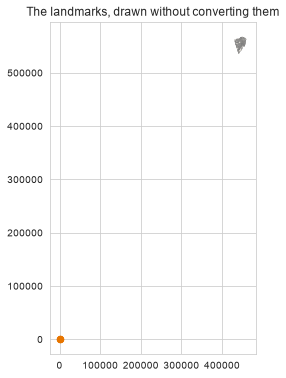

In [14]:
landmarks = pd.read_csv("data/landmarks.csv")
places = gpd.GeoDataFrame(
    landmarks,
    geometry=gpd.points_from_xy(landmarks["lon"], landmarks["lat"]),
    crs="EPSG:4326",
)

ax = zoning.plot(figsize=(6, 6), color="#f5f0e6", edgecolor="grey", linewidth=0.3)
places.plot(ax=ax, color="#e77500", markersize=40)
ax.set_title("The landmarks, drawn without converting them")

Ignore the line of text above the picture. It is Python echoing the title it just set, and it appears whenever the last line of a cell hands something back. The picture is what matters, and there is no error, no warning, and a map that is wrong in a way you have to look at to see. The horizontal axis now runs from below zero to nearly half a million, because the plot stretched itself to hold both layers. The town, some thirty thousand feet across, has become a small shape in one corner. The three landmarks sit near the origin, at about minus seventy four and forty, because this layer reads their degrees as feet and puts them far outside New Jersey. All three are within a mile of each other, so at this scale they are one dot in the corner of the frame.

Let us look at what the axes actually span:

In [15]:
ax.get_xlim(), ax.get_ylim()

((np.float64(-23048.989513326604), np.float64(482386.2707798586)),
 (np.float64(-28327.7055255224), np.float64(595769.3756759705)))

Those limits are the diagnosis. A map whose axis runs from a small negative number to hundreds of thousands is a map that has been asked to hold two coordinate systems at once. Here is the same picture with the landmarks converted into the zoning layer's own system first:

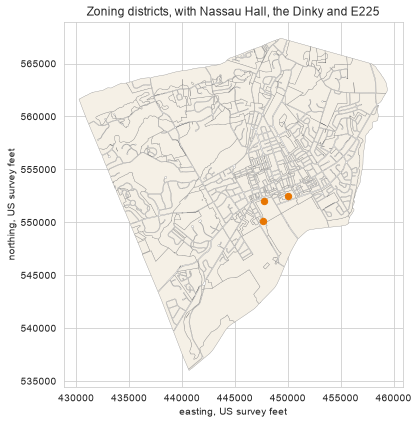

In [16]:
ax = zoning.plot(figsize=(6, 6), color="#f5f0e6", edgecolor="grey", linewidth=0.3)
places.to_crs(zoning.crs).plot(ax=ax, color="#e77500", markersize=40)
ax.set_title("Zoning districts, with Nassau Hall, the Dinky and E225")
ax.set_xlabel("easting, US survey feet")
ax.set_ylabel("northing, US survey feet")
fig = ax.figure
fig.tight_layout()

Note the axis labels. In P01 we hid the axes on the finished map. On a working map we leave them on, precisely because they are the fastest way to catch this mistake. New Jersey's feet put both numbers in the hundreds of thousands, UTM metres put the easting in the hundreds of thousands and the northing in the millions, and degrees are in the tens, so the northing on the frame is what tells you which one you are in.

## Two versions of one datum, and one warning

The zoning layer is in EPSG:6527 and the tax blocks in EPSG:3424, the same feet on two realisations of the datum. Let us ask which zoning districts touch which blocks, i.e. a spatial join, without converting either:

In [17]:
joined = gpd.sjoin(zoning, blocks[["BLOCK_NO", "geometry"]], predicate="intersects")
len(joined)

/var/folders/yk/vz7vdkds0ld4lh886p4v3lbh0000gn/T/ipykernel_85614/1991304688.py:1: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:6527
Right CRS: EPSG:3424

  joined = gpd.sjoin(zoning, blocks[["BLOCK_NO", "geometry"]], predicate="intersects")


910

Read the warning above the number. geopandas noticed that the two layers are in different coordinate reference systems, said so, and then did the join anyway, comparing feet on one datum with feet on the other as if they were the same numbers. Note that the 910 counts neither districts nor blocks but pairs, i.e. one row for every pair of a district and a block that touch, which is why it is larger than either layer. The count looks plausible, and in a moment we find out whether it was right.

This is the dangerous kind of mismatch. When the systems were degrees against feet, the picture collapsed and the mistake was impossible to miss. Here the result looks right, and the only thing between you and a subtly wrong answer is a warning you have to choose to read. Let us do what the warning asks, convert the blocks into the zoning layer's system, and join again, and this time also measure how far the conversion moved the blocks:

In [18]:
blocks_ft = blocks.to_crs(zoning.crs)
joined = gpd.sjoin(zoning, blocks_ft[["BLOCK_NO", "geometry"]], predicate="intersects")

before = blocks.geometry.centroid
after = blocks_ft.geometry.centroid
moved = (((before.x - after.x) ** 2 + (before.y - after.y) ** 2) ** 0.5).max()
print(f"{len(joined)} rows, and the conversion moved no block's centre by more than {moved:.4f} ft")

910 rows, and the conversion moved no block's centre by more than 0.0000 ft


The same count, twice, this time without a warning, and the last number is the surprise. The conversion moved every block by exactly nothing. The two realisations really are up to a metre apart on the ground, but pyproj, the library underneath geopandas, has no precise transformation between this pair and applies a zero shift, so the converted coordinates are identical to the digit. The warning was the only evidence that anything was ever wrong, and that is the whole point. The next time two systems differ, the gap may be four hundred kilometres rather than nothing, the join will still run, and the number it returns will be wrong by an amount nobody can see. A warning about coordinate systems is never noise, and the fix is one call.

## A number that must agree with itself

The stormwater inlets layer records each inlet twice, once as a geometry and once as a pair of columns called `Easting` and `Northing` that somebody typed beside it. `inlets.geometry.x` is the easting of each point as the geometry has it, and the line below measures the distance between the two records of every inlet. Two records of the same fact ought to agree, and checking that they do is the cheapest verification there is:

In [19]:
inlets = gpd.read_file("data/princeton_municipal.gpkg", layer="stormwater_inlets")

gap = ((inlets.geometry.x - inlets["Easting"]) ** 2 + (inlets.geometry.y - inlets["Northing"]) ** 2) ** 0.5
print(f"typical disagreement  {gap.median():.3f} ft")
print(f"rows over one foot    {int((gap > 1).sum())}")
print(f"worst                 {gap.max():.0f} ft")

typical disagreement  0.000 ft
rows over one foot    31
worst                 223 ft


For the typical inlet the geometry and the stored coordinates agree to better than a hundredth of a foot. That is a free proof that the layer really is in the feet it claims, since a geometry in metres or degrees would disagree with these columns by a great deal. A few dozen rows disagree by up to a couple of hundred feet, and we do not fix them here. The self-paced notebook 02-05 maps them, and they are the kind of thing a careful reader of any dataset finds within an hour. Two numbers that should match, and mostly do, is the check that caught the 513 square kilometre error at rehearsal, and it will catch things for you all semester.

## The click, in code

In QGIS you click a parcel and a panel shows you its row. In code, the click is a predicate. The landmarks table has an `id` column, and `set_index("id").loc["e225", "geometry"]` picks out the geometry of the row whose id is e225, i.e. this classroom. We put that point into the parcel layer's coordinate system and ask which parcels contain it, with `contains`, which is the `within` of 01-07 asked from the polygon's side:

In [20]:
parcels = gpd.read_file("data/princeton_municipal.gpkg", layer="parcels")

e225 = places.set_index("id").loc["e225", "geometry"]
e225_ft = gpd.GeoSeries([e225], crs="EPSG:4326").to_crs(parcels.crs).iloc[0]

parcels[parcels.contains(e225_ft)][["block", "lot", "qualifier", "property_location"]]

,block,lot,qualifier,property_location
305,48.01,20,NaN,OLDEN ST-MASTER LOT
870,48.01,20,D01,ENGINEERING QUAD E-WING


Two rows, which is one more than a point in a parcel map ought to return. The reason is in the `qualifier` column. The University's land along Olden Street is one master lot, and the buildings on it are recorded as pieces of that lot with a qualifier, the way flats in a block are recorded as pieces of one building. The point sits in the master lot and in the E-Wing at once. Note that this is the same lesson as 01-07, i.e. a spatial question can have more than one true answer, and you have to say which one you counted.

The municipality's parcel layer has no money in it. The State of New Jersey publishes the same parcels joined to the tax roll, which is where the assessed value lives. Let us read it and, before anything else, ask what it arrived in:

In [21]:
tax_roll = gpd.read_file("data/njgin_parcels.gpkg", layer="parcels")
tax_roll.crs

<Projected CRS: EPSG:3857>
Name: WGS 84 / Pseudo-Mercator
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: World between 85.06°S and 85.06°N.
- bounds: (-180.0, -85.06, 180.0, 85.06)
Coordinate Operation:
- name: Popular Visualisation Pseudo-Mercator
- method: Popular Visualisation Pseudo Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

A third system in one folder. `EPSG:3857` is Web Mercator, the projection every web map uses so that square tiles fit at every zoom. It is measured in metres, which makes it look safe, and at our latitude it stretches every distance by about 31 percent and every area by about 72 percent, which makes it the subtle trap the lecture warned about. We do not measure anything in it. We convert the point into it, ask the same question, and read the row:

In [22]:
e225_wm = gpd.GeoSeries([e225], crs="EPSG:4326").to_crs(tax_roll.crs).iloc[0]

tax_roll[tax_roll.contains(e225_wm)][["PAMS_PIN", "PROP_CLASS", "PROP_LOC", "BLDG_DESC", "NET_VALUE", "CALC_ACRE"]]

,PAMS_PIN,PROP_CLASS,PROP_LOC,BLDG_DESC,NET_VALUE,CALC_ACRE
2155,1114_48.01_20_D01,15B,ENGINEERING QUAD E-WING,"ACAD 47,303SF",10448100,0.8


There is the room we are sitting in, as the tax assessor sees it. `PAMS_PIN` is the State's identifier for the parcel, built from the town, the block, the lot and the qualifier, and it is the name 02-02 counts parcels by. A property class of `15B` means other school property, i.e. land that is assessed but exempt from tax, and the row carries the building's description, its assessed value in dollars and its size in acres.

Note what is not in the row. The State's file carries the owner's name and mailing address upstream, and the municipality strips them from its own layer before publishing. The course's pipeline never requested them, so they never reached your disk. The property location that is in the row is the parcel's street address, which names a piece of land and not a person. Owners are people, and this course maps land by its class, its use and its value, in aggregate, and never by who owns it. That is a decision, not an accident, and 02-05 comes back to it.

## Check your understanding

1. The zoning layer reported about 476 million and the P01 boundary 47.66 for the same town. Name the unit of each, and the single call that turns the first into a number you can compare with the second.
2. Drawing the landmarks over the zoning map without converting them produced no error. What did the horizontal axis look like, and what one glance would have caught it on any map?
3. The join between EPSG:6527 and EPSG:3424 came back with a plausible count and a warning. Why is that more dangerous than the join that draws nothing, and what is the fix?
4. The click on E225 returned two parcels. Why, and what would you have to say about the count if you were reporting how many parcels the University holds?

## Where we are

You can open a GeoPackage and list what is in it, read what a layer says about its own coordinate system and datum, and tell feet from metres from degrees by looking at an axis. You have made the 513 mistake on real municipal data and undone it with one call, and you have seen the quieter version of the same mistake, where two systems a metre apart join with a warning and a plausible number. You have checked one file against itself, where a geometry and a typed pair of columns agree to better than a hundredth of a foot. And you have found the row behind this classroom in two authorities' files.

The habit worth keeping: ask every layer for its CRS before you measure or join it, and treat a warning about coordinate systems as an instruction rather than as noise.

In 02-02 we take this file and turn the State's parcels into one number per block, and meet the join that counts things twice.

## Further resources

Nothing in this course requires anything below.

The GeoPackage format is an open standard maintained by the Open Geospatial Consortium, and its home page explains what a file can hold: https://www.geopackage.org/

EPSG codes are looked up at https://epsg.io, where https://epsg.io/6527 and https://epsg.io/3424 each name their datum, projection and unit, and the official registry behind them is at https://epsg.org.

The municipal layers in this notebook are published by the Municipality of Princeton through its ArcGIS Online organisation and are public records. The parcels with the tax roll are published by NJGIN Open Data, the State of New Jersey's geographic information network, which asks that it be acknowledged: https://njogis-newjersey.opendata.arcgis.com/